In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

df = pd.read_csv("/Users/gabsasp/Documents/SuperProjeto/WorldCupMatches.csv")
df.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,2549.0,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,23409.0,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA


### 📥 Carregamento dos dados

**Insight:** O dataset `WorldCupMatches.csv` reúne o histórico de partidas de Copas do Mundo. Já no `head()` percebe-se a riqueza de informações por jogo: ano, estádio, cidade, mandante/visitante, gols, público e arbitragem. Esse será o ponto de partida para limpeza e análise.

In [2]:
# obs: Year está como Float e datetime está como object, mudar depois!!
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  852 non-null    float64
 1   Datetime              852 non-null    object 
 2   Stage                 852 non-null    object 
 3   Stadium               852 non-null    object 
 4   City                  852 non-null    object 
 5   Home Team Name        852 non-null    object 
 6   Home Team Goals       852 non-null    float64
 7   Away Team Goals       852 non-null    float64
 8   Away Team Name        852 non-null    object 
 9   Win conditions        852 non-null    object 
 10  Attendance            850 non-null    float64
 11  Half-time Home Goals  852 non-null    float64
 12  Half-time Away Goals  852 non-null    float64
 13  Referee               852 non-null    object 
 14  Assistant 1           852 non-null    object 
 15  Assistant 2          

### 🔍 Inspeção dos tipos de dados

**Insight:** O `df.info()` revela dois problemas de tipagem: `Year` está como `float64` (deveria ser inteiro) e `Datetime` está como `object` (texto, e não data). Além disso, das 4572 linhas, apenas **852** têm valores preenchidos — sinal claro de que o arquivo tem muitas linhas vazias que precisarão ser tratadas.

In [3]:
# Ver valores "Null" em cada coluna 
print("valores null em cada coluna:")
print(df.isnull().sum())


valores null em cada coluna:
Year                    3720
Datetime                3720
Stage                   3720
Stadium                 3720
City                    3720
Home Team Name          3720
Home Team Goals         3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Attendance              3722
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64


### 🕳️ Contagem de valores nulos

**Insight:** Praticamente todas as colunas têm **3720 valores nulos** — exatamente a diferença entre 4572 e 852. Isso confirma que existem 3720 linhas completamente vazias no arquivo. A coluna `Attendance` tem 2 nulos a mais (3722), indicando que além das linhas vazias há também jogos reais sem público registrado.

Dataset possui apenas 852 partidas registradas, ou seja, muitas colunas são completamente irrelevantes com valores nulos

In [4]:
# dropar linhas com valores nulos
df.dropna(subset=['Year','Datetime','Home Team Name', 'Away Team Name'],inplace = True)

# Verificar valores nulos novamente
print(df.isnull().sum())

Year                    0
Datetime                0
Stage                   0
Stadium                 0
City                    0
Home Team Name          0
Home Team Goals         0
Away Team Goals         0
Away Team Name          0
Win conditions          0
Attendance              2
Half-time Home Goals    0
Half-time Away Goals    0
Referee                 0
Assistant 1             0
Assistant 2             0
RoundID                 0
MatchID                 0
Home Team Initials      0
Away Team Initials      0
dtype: int64


### 🧹 Remoção das linhas vazias

**Insight:** Usando `dropna()` em colunas-chave (`Year`, `Datetime`, mandante e visitante), as 3720 linhas fantasmas desaparecem de uma vez. O dataset cai para 852 partidas reais e válidas. Resta apenas um resíduo: **2 partidas sem público** (`Attendance`), que serão tratadas a seguir.

In [5]:
# Devido a natureza esquisita dessas duas linhas de attendance com valores nulos, 
# acho justificavel colocar a media da coluna como valor
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean())
print(df.isnull().sum())

Year                    0
Datetime                0
Stage                   0
Stadium                 0
City                    0
Home Team Name          0
Home Team Goals         0
Away Team Goals         0
Away Team Name          0
Win conditions          0
Attendance              0
Half-time Home Goals    0
Half-time Away Goals    0
Referee                 0
Assistant 1             0
Assistant 2             0
RoundID                 0
MatchID                 0
Home Team Initials      0
Away Team Initials      0
dtype: int64


### 🩹 Imputação do público faltante

**Insight:** Em vez de descartar as 2 partidas sem público, optou-se por **preencher com a média da coluna** (`fillna(mean)`). É uma escolha conservadora: mantém os jogos na análise sem distorcer demais a distribuição de público. Após isso, o dataset fica **100% sem valores nulos**.

In [6]:
# Converter Ano para integer
df["Year"] = df["Year"].astype(int)

df["Home Team Goals"] = df["Home Team Goals"].astype(int)
df["Away Team Goals"] = df["Away Team Goals"].astype(int)

# Converter Datetime para DateTime
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")

df.dtypes

Year                             int64
Datetime                datetime64[ns]
Stage                           object
Stadium                         object
City                            object
Home Team Name                  object
Home Team Goals                  int64
Away Team Goals                  int64
Away Team Name                  object
Win conditions                  object
Attendance                     float64
Half-time Home Goals           float64
Half-time Away Goals           float64
Referee                         object
Assistant 1                     object
Assistant 2                     object
RoundID                        float64
MatchID                        float64
Home Team Initials              object
Away Team Initials              object
dtype: object

### 🔧 Correção dos tipos de dados

**Insight:** Conversões essenciais para análise correta: `Year` e os gols viram inteiros (não faz sentido "1930.0" gols), e `Datetime` passa a ser um objeto de data/hora de verdade. Isso desbloqueia operações temporais (extrair ano/mês/dia, ordenar por data) e cálculos numéricos limpos nos próximos passos.

In [7]:
# Criar coluna "Goal Difference" subtraindo os gols do time da casa e os gols do time visitante
df["Goal Differences"] = df["Home Team Goals"] - df["Away Team Goals"]

# Criar coluna "Match Result" para indicar Vitoria/Derrota/Empate
df["Match Result"] = df.apply(lambda row: "Home win" if row["Home Team Goals"] > row["Away Team Goals"] else
("Away Win" if row["Home Team Goals"] < row["Away Team Goals"] else "Draw"), axis=1)

print(df.head(5))

   Year            Datetime    Stage         Stadium         City  \
0  1930 1930-07-13 15:00:00  Group 1         Pocitos  Montevideo    
1  1930 1930-07-13 15:00:00  Group 4  Parque Central  Montevideo    
2  1930 1930-07-14 12:45:00  Group 2  Parque Central  Montevideo    
3  1930 1930-07-14 14:50:00  Group 3         Pocitos  Montevideo    
4  1930 1930-07-15 16:00:00  Group 1  Parque Central  Montevideo    

  Home Team Name  Home Team Goals  Away Team Goals Away Team Name  \
0         France                4                1         Mexico   
1            USA                3                0        Belgium   
2     Yugoslavia                2                1         Brazil   
3        Romania                3                1           Peru   
4      Argentina                1                0         France   

  Win conditions  ...  Half-time Away Goals                 Referee  \
0                 ...                   0.0  LOMBARDI Domingo (URU)   
1                 ...       

### ➕ Engenharia de atributos: resultado da partida

**Insight:** Duas colunas derivadas dão poder analítico ao dataset: `Goal Differences` (saldo de gols do mandante) e `Match Result`, que rotula cada jogo como **Home win / Away Win / Draw**. Essa coluna categórica será o **alvo** do modelo de classificação (Naive Bayes) construído mais adiante.

In [8]:
# Obter ano, mes e dia da coluna "Datetime"
df['Match Year'] = df['Datetime'].dt.year
df['Match Month'] = df['Datetime'].dt.month
df['Match Day'] = df['Datetime'].dt.day

print(df[["Datetime","Match Year", "Match Month", "Match Day"]].head())

             Datetime  Match Year  Match Month  Match Day
0 1930-07-13 15:00:00      1930.0          7.0       13.0
1 1930-07-13 15:00:00      1930.0          7.0       13.0
2 1930-07-14 12:45:00      1930.0          7.0       14.0
3 1930-07-14 14:50:00      1930.0          7.0       14.0
4 1930-07-15 16:00:00      1930.0          7.0       15.0


### 📅 Decomposição da data

**Insight:** A partir de `Datetime` extraem-se `Match Year`, `Match Month` e `Match Day`. Separar os componentes da data facilita análises de sazonalidade (ex.: em que meses as Copas acontecem) e cruzamentos temporais sem precisar manipular a data completa toda vez.

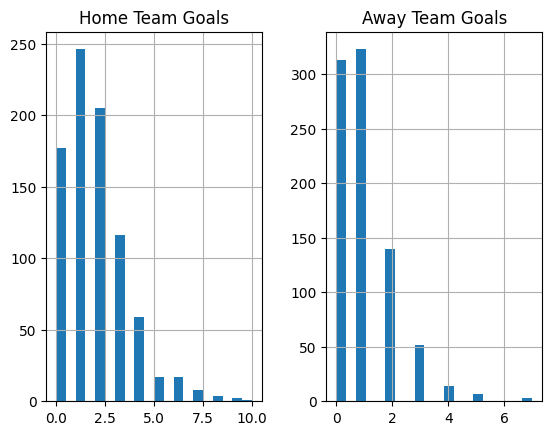

In [9]:
df[['Home Team Goals', 'Away Team Goals']].hist(bins=20)
plt.show()

### 📊 Distribuição dos gols (mandante x visitante)

**Insight:** Os histogramas mostram que a maioria das partidas tem **poucos gols** (concentração em 0, 1 e 2), com uma cauda longa para placares altos. O time da casa tende a marcar mais gols com mais frequência do que o visitante — primeira evidência visual da **vantagem de jogar em casa**.

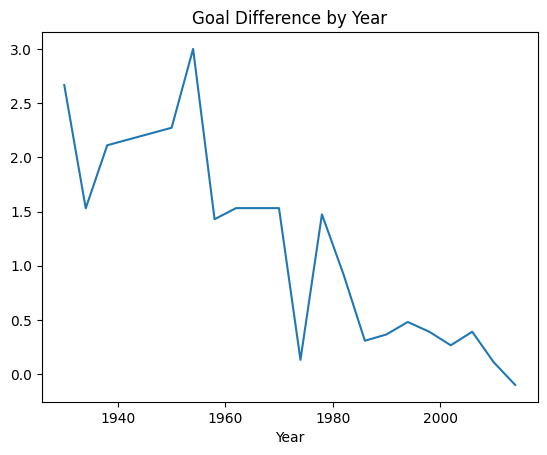

In [10]:
df['Goal Difference'] = df['Home Team Goals'] - df['Away Team Goals']
df.groupby('Year')['Goal Difference'].mean().plot(kind='line')
plt.title("Goal Difference by Year")
plt.show()

### 📈 Saldo de gols médio ao longo dos anos

**Insight:** O gráfico de linha mostra como o **saldo médio de gols do mandante** variou Copa a Copa. As primeiras edições tendem a apresentar saldos mais extremos (poucos jogos, placares elásticos), enquanto as Copas modernas convergem para saldos menores — reflexo de um futebol mais equilibrado e taticamente fechado.

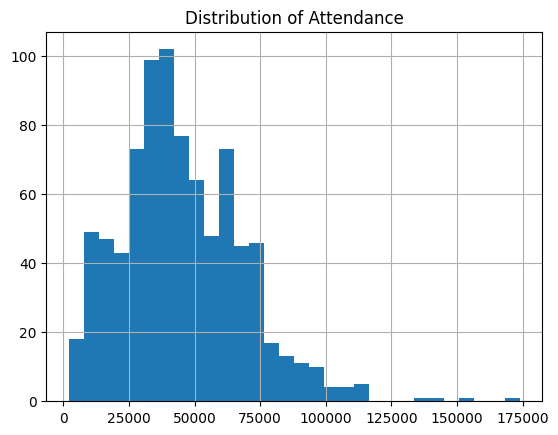

In [11]:
df['Attendance'].hist(bins=30)
plt.title("Distribution of Attendance")
plt.show()

### 👥 Distribuição do público

**Insight:** O histograma de `Attendance` é fortemente **assimétrico à direita**: a maioria dos jogos tem público moderado, mas alguns poucos (finais, jogos no Maracanã) atraem multidões. Essa cauda longa justifica, mais adiante, dividir o público em **tercis (Baixo/Médio/Alto)** em vez de usar o valor bruto no modelo.

In [12]:
# Melhores times/Times com mais gols
home_team_goals = df.groupby('Home Team Name')['Home Team Goals'].sum()
away_team_goals = df.groupby('Away Team Name')['Away Team Goals'].sum()
total_goals = home_team_goals + away_team_goals
total_goals.sort_values(ascending=False).head(5)

Brazil        225.0
Argentina     133.0
Germany FR    131.0
Italy         128.0
France        108.0
dtype: float64

### 🏆 Maiores artilheiros (somando casa + visitante)

**Insight:** Somando os gols como mandante e visitante, o **Brasil lidera com folga (225 gols)**, seguido por Argentina (133), Alemanha (131), Itália (128) e França (108). O ranking espelha as potências históricas do futebol e confirma a hegemonia brasileira em volume de gols nas Copas.

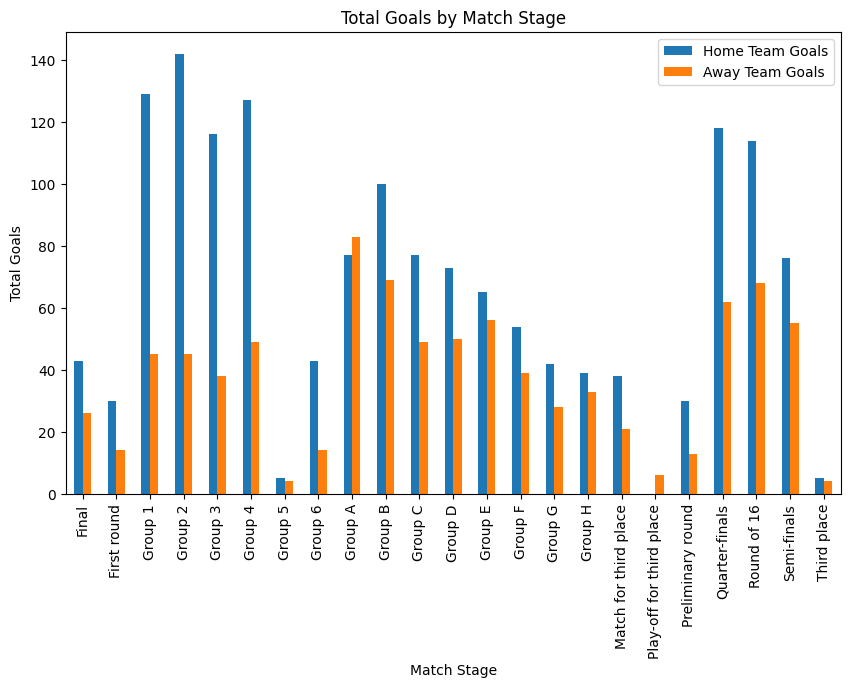

In [13]:
# Obs: Grupos 1,2,3,4 se referem aos grupos das primeiras copas!!

stage_results = df[['Stage', 'Home Team Goals', 'Away Team Goals']].groupby('Stage').sum()


stage_results.plot(kind='bar', figsize=(10, 6))
plt.title("Total Goals by Match Stage")
plt.xlabel("Match Stage")
plt.ylabel("Total Goals")
plt.show()

### 🥅 Gols por fase da competição

**Insight:** Agrupando por `Stage`, fica evidente que a **fase de grupos concentra a maior parte dos gols** — simplesmente porque há muito mais jogos nessa etapa do que nas fases de mata-mata. Vale a ressalva do código: "Group 1/2/3/4" referem-se aos grupos das primeiras Copas, o que fragmenta a contagem entre rótulos antigos e modernos.

In [14]:
# Media de attendence, junto com a partida com maior e menor.
 
media_attendance = df['Attendance'].mean()

maior_attendance = df.loc[df['Attendance'].idxmax()]

menor_attendance = df.loc[df['Attendance'].idxmin()]
 
print(f"Media de attendance: {media_attendance:.2f}")
print(f"Maior attendance:\n{maior_attendance}")
print(f"Menor Attendence:\n{menor_attendance}") 

Media de attendance: 45164.80
Maior attendance:
Year                                                         1950
Datetime                                      1950-07-16 15:00:00
Stage                                                     Group 6
Stadium                 Maracan� - Est�dio Jornalista M�rio Filho
City                                              Rio De Janeiro 
Home Team Name                                            Uruguay
Home Team Goals                                                 2
Away Team Goals                                                 1
Away Team Name                                             Brazil
Win conditions                                                   
Attendance                                               173850.0
Half-time Home Goals                                          0.0
Half-time Away Goals                                          0.0
Referee                                       READER George (ENG)
Assistant 1                 

### 🎫 Extremos de público

**Insight:** O público médio é de **~45.165 torcedores**. O extremo máximo é icônico: **Uruguai 2 x 1 Brasil, na final de 1950 no Maracanã, com 173.850 pessoas** (o "Maracanazo"). No outro extremo, **Chile 1 x 0 França em 1930** teve apenas 2.000 espectadores. O contraste mostra a evolução da Copa de um torneio modesto para um megaevento global.

In [15]:
# Cidades com maior quantidades de partidas
matches_cidades = df['City'].value_counts()

print("Cities that hosted the most World Cup Matches:")
print(matches_cidades.head(5))

Cities that hosted the most World Cup Matches:
City
Mexico City        23
Montevideo         18
Rio De Janeiro     18
Guadalajara        17
Johannesburg       15
Name: count, dtype: int64


### 🌎 Cidades-sede com mais jogos

**Insight:** **Cidade do México lidera (23 partidas)**, seguida por Montevidéu e Rio de Janeiro (18 cada), Guadalajara (17) e Joanesburgo (15). O destaque mexicano se explica por ter sediado duas Copas (1970 e 1986) com grandes estádios, enquanto Montevidéu e Rio refletem o peso histórico das primeiras edições na América do Sul.

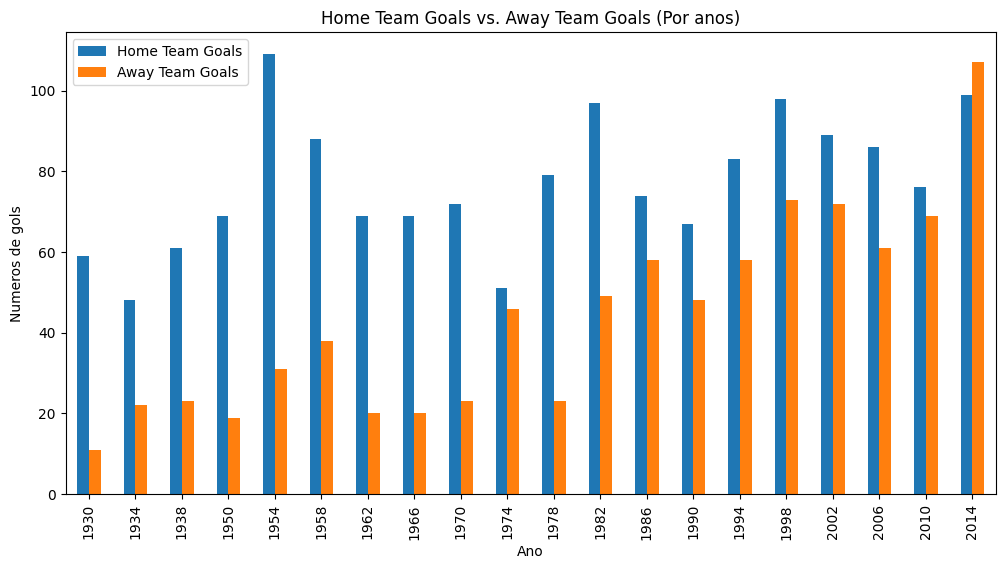

In [16]:
# Group data by year and calculate total home and away goals
goals_by_year = df.groupby('Year')[['Home Team Goals', 'Away Team Goals']].sum()

goals_by_year.plot(kind='bar', figsize=(12,6))
plt.title('Home Team Goals vs. Away Team Goals (Por anos)')
plt.ylabel('Numeros de gols')
plt.xlabel('Ano')
plt.legend(['Home Team Goals', 'Away Team Goals'])
plt.show()

### 🏟️ Gols de mandante x visitante por ano

**Insight:** O gráfico de barras comparando gols de mandante e visitante ano a ano reforça, de forma consistente ao longo da história, que **os mandantes marcam mais que os visitantes** na maioria das edições. É a confirmação numérica do "fator casa" — fenômeno que o modelo de classificação a seguir tentará capturar.

In [17]:
# Preparação: criar as preditoras categóricas

# (a) Stage -> "Fase de Grupos" vs "Mata-mata"
df["Stage_cat"] = df["Stage"].apply(
    lambda s: "Fase de Grupos" if str(s).startswith(("Group", "First", "Preliminary")) else "Mata-mata"
)

# (b) Attendance -> tercis Baixo / Médio / Alto
df["Attendance_cat"], faixas = pd.qcut(
    df["Attendance"], q=3, labels=["Baixo", "Médio", "Alto"], retbins=True
)

alvo = "Match Result"
preditoras = ["Stage_cat", "Attendance_cat", "Home Team Name"]
classes = df[alvo].unique()

print("Faixas de público:", faixas.round(0))
print(f"\nTotal de partidas: {len(df)}\n")
print(df[alvo].value_counts())

Faixas de público: [  2000.  33619.  53181. 173850.]

Total de partidas: 852

Match Result
Home win    488
Draw        190
Away Win    174
Name: count, dtype: int64


## 🤖 Modelo Naive Bayes — Preparação dos atributos

**Insight:** Aqui começa a modelagem. Definem-se as **preditoras categóricas**: `Stage_cat` (Fase de Grupos vs Mata-mata) e `Attendance_cat` (público em tercis Baixo/Médio/Alto, com cortes em ~33.619 e ~53.181) e o time mandante. O **alvo** é `Match Result`. O balanço das classes já antecipa o desafio: **57% Home win, 22% Draw, 20% Away Win** — dataset desbalanceado e enviesado para a vitória do mandante.

In [18]:
# PASSO 1 — Probabilidades A PRIORI  P(C) = frequência de cada classe
priori = df[alvo].value_counts(normalize=True)

print("Probabilidades a priori P(C):")
print(priori.round(4))

Probabilidades a priori P(C):
Match Result
Home win    0.5728
Draw        0.2230
Away Win    0.2042
Name: proportion, dtype: float64


### 1️⃣ Probabilidades a priori — P(C)

**Insight:** Sem olhar nenhuma característica do jogo, a melhor aposta já é "vitória do mandante" (**57,3%**). Empate (22,3%) e vitória do visitante (20,4%) completam o quadro. Essas probabilidades a priori são o ponto de partida do Bayes — qualquer evidência (fase, público, time) vai ajustar essa crença inicial.

In [19]:
# PASSO 2 — VEROSSIMILHANÇA  P(x_i = valor | C)  com suavização de Laplace (alpha=1)
#
#                   contagem(x_i = valor, C) + 1
#   P(x_i | C) = ---------------------------------
#                     contagem(C) + 1 * k          (k = nº de categorias da preditora)
#
# A suavização evita probabilidade zero para combinações nunca vistas no histórico.

def verossimilhanca(feature, valor, classe, alpha=1):
    sub = df[df[alvo] == classe]
    k = df[feature].nunique()
    return ((sub[feature] == valor).sum() + alpha) / (len(sub) + alpha * k)

# Exemplo: P(Stage_cat | classe)
print("P(Stage_cat | Match Result):")
for c in classes:
    print(f"  {c:9s}: Grupos={verossimilhanca('Stage_cat','Fase de Grupos',c):.3f}  "
          f"Mata-mata={verossimilhanca('Stage_cat','Mata-mata',c):.3f}")

P(Stage_cat | Match Result):
  Home win : Grupos=0.720  Mata-mata=0.280
  Draw     : Grupos=0.828  Mata-mata=0.172
  Away Win : Grupos=0.739  Mata-mata=0.261


### 2️⃣ Verossimilhança — P(xᵢ | C) com suavização de Laplace

**Insight:** Calcula-se a probabilidade de cada característica dado o resultado. A **suavização de Laplace (alpha=1)** é crucial: evita probabilidade zero para combinações nunca vistas (ex.: um time específico que nunca empatou no histórico), o que zeraria todo o produto bayesiano. Curiosidade nos números: os **empates são proporcionalmente mais comuns na fase de grupos (82,8%)** do que no mata-mata — coerente, já que o mata-mata força um vencedor.

In [20]:
# PASSO 3 — TEOREMA DE BAYES -> probabilidade A POSTERIORI
#
#                P(C) * Π P(x_i | C)
#   P(C | x) = -----------------------
#                Σ_C P(C) * Π P(x_i | C)

def classificar_partida(stage, attendance, home_team):
    # Traduz a entrada do usuário para as categorias do modelo
    x = {
        "Stage_cat": "Fase de Grupos" if str(stage).startswith(("Group", "First", "Preliminary")) else "Mata-mata",
        "Attendance_cat": str(pd.cut([attendance], bins=faixas,
                                     labels=["Baixo", "Médio", "Alto"], include_lowest=True)[0]),
        "Home Team Name": home_team,
    }

    # Numerador de Bayes para cada classe: P(C) * Π P(x_i | C)
    scores = {}
    for c in classes:
        p = priori[c]
        for f in preditoras:
            p *= verossimilhanca(f, x[f], c)
        scores[c] = p

    # Normaliza para obter as probabilidades a posteriori
    total = sum(scores.values())
    posteriori = {c: scores[c] / total for c in classes}

    print(f"Entrada -> Fase='{x['Stage_cat']}', Público='{x['Attendance_cat']}', Mandante='{home_team}'\n")
    print("Probabilidades a posteriori P(C | x):")
    for c in sorted(posteriori, key=posteriori.get, reverse=True):
        print(f"  P({c:9s} | x) = {posteriori[c]:.4f}")
    pred = max(posteriori, key=posteriori.get)
    print(f"\n  ==> Classe prevista: {pred}  ({posteriori[pred]*100:.1f}%)")
    return posteriori

### 3️⃣ Teorema de Bayes — probabilidade a posteriori

**Insight:** Esta função junta tudo: multiplica a priori P(C) pelas verossimilhanças de cada característica (assumindo **independência** entre elas — a hipótese "naive") e normaliza para obter P(C | x). O resultado é um classificador que, dado fase, público e time mandante, devolve a probabilidade de cada desfecho e escolhe o mais provável. É o coração do modelo.

In [21]:
# EXEMPLO — características de uma NOVA partida informadas pelo usuário
_ = classificar_partida(
    stage="Quarter-finals",   # -> Mata-mata
    attendance=70000,         # -> faixa Alto
    home_team="Brazil",       # time mandante
)

Entrada -> Fase='Mata-mata', Público='Alto', Mandante='Brazil'

Probabilidades a posteriori P(C | x):
  P(Home win  | x) = 0.8110
  P(Away Win  | x) = 0.0980
  P(Draw      | x) = 0.0910

  ==> Classe prevista: Home win  (81.1%)


### ✅ Exemplo de classificação

**Insight:** Testando o modelo numa partida hipotética — **Brasil mandante, quartas de final, público alto** — ele prevê **vitória do mandante com 81,1%** de confiança, bem acima dos 57% da priori. Ou seja, saber que o mandante é o Brasil reforça fortemente a aposta na vitória da casa. Empate (9,1%) e derrota (9,8%) ficam quase descartados. O classificador funciona e combina, de forma intuitiva, o fator casa com a força histórica da seleção.

# 🧪 Seção 4 — Algoritmos de Classificação e Comparação

Até aqui, o **Teorema de Bayes** foi implementado "na mão" para estimar a probabilidade de cada resultado. Nesta seção, treinamos **dois algoritmos de classificação supervisionada** — **Árvore de Decisão** e **K-Nearest Neighbors (KNN)** — e os comparamos entre si e com a abordagem bayesiana.

**Metodologia:**
- **Alvo:** `Match Result` (Home win / Draw / Away Win)
- **Preditoras:** `Stage_cat` (fase), `Attendance_cat` (público) e `Home Team Name` (mandante)
- **Divisão:** treino/teste com `train_test_split` estratificado (75% / 25%) para avaliação justa em dados *não vistos*
- **Métricas:** Acurácia, Precisão, Recall, F1-score (média ponderada) e Matriz de Confusão
- **Baseline de referência:** prever sempre "Home win" acerta ~57,3% (a classe majoritária). Qualquer modelo útil precisa superar esse patamar.

In [22]:
# ----- Preparação: codificação das preditoras e divisão treino/teste -----

preditoras = ["Stage_cat", "Attendance_cat", "Home Team Name"]
alvo = "Match Result"
rotulos = ["Home win", "Draw", "Away Win"]   # ordem fixa p/ matrizes de confusão

dados = df[preditoras + [alvo]].copy()

# One-Hot Encoding: algoritmos de ML exigem entradas numéricas
X = pd.get_dummies(dados[preditoras])
y = dados[alvo]

# Split estratificado: mantém a proporção das classes em treino e teste
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, dados.index, test_size=0.25, random_state=42, stratify=y
)

print(f"Total de partidas .....: {len(dados)}")
print(f"Treino ................: {len(X_train)} partidas")
print(f"Teste .................: {len(X_test)} partidas")
print(f"Atributos após One-Hot : {X.shape[1]} colunas")
print(f"\nDistribuição no teste:\n{y_test.value_counts()}")

# Função utilitária para padronizar a coleta de métricas
def avaliar(nome, y_true, y_pred):
    return {
        "Modelo":   nome,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall":   recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

resultados = []          # acumula as métricas de cada modelo
predicoes  = {}          # guarda y_pred de cada modelo p/ matrizes de confusão

Total de partidas .....: 852
Treino ................: 639 partidas
Teste .................: 213 partidas
Atributos após One-Hot : 83 colunas

Distribuição no teste:
Match Result
Home win    122
Draw         47
Away Win     44
Name: count, dtype: int64


In [23]:
# ===== MODELO 1 — Teorema de Bayes (Naive Bayes manual) =====
# Reimplementado para treinar APENAS no conjunto de treino (evita vazamento de dados)
# e ser avaliado no conjunto de teste, em igualdade de condições com os demais.

train_df = dados.loc[idx_train]
test_df  = dados.loc[idx_test]

def treinar_bayes_manual(train_df, preditoras, alvo, alpha=1):
    classes = train_df[alvo].unique()
    priori  = train_df[alvo].value_counts(normalize=True).to_dict()
    contagens, k = {}, {f: train_df[f].nunique() for f in preditoras}
    for c in classes:
        sub = train_df[train_df[alvo] == c]
        contagens[c] = {"_n": len(sub)}
        for f in preditoras:
            contagens[c][f] = sub[f].value_counts().to_dict()

    def prever(row):
        scores = {}
        for c in classes:
            p = priori[c]
            for f in preditoras:                       # suavização de Laplace
                cont = contagens[c][f].get(row[f], 0)
                p *= (cont + alpha) / (contagens[c]["_n"] + alpha * k[f])
            scores[c] = p
        return max(scores, key=scores.get)
    return prever

prever_bayes = treinar_bayes_manual(train_df, preditoras, alvo)
y_pred_bayes = test_df.apply(prever_bayes, axis=1)

predicoes["Teorema de Bayes"] = y_pred_bayes
resultados.append(avaliar("Teorema de Bayes", y_test, y_pred_bayes))

print("===== Teorema de Bayes (Naive Bayes manual) =====\n")
print(classification_report(y_test, y_pred_bayes, zero_division=0))

===== Teorema de Bayes (Naive Bayes manual) =====

              precision    recall  f1-score   support

    Away Win       0.46      0.25      0.32        44
        Draw       0.20      0.06      0.10        47
    Home win       0.65      0.93      0.76       122

    accuracy                           0.60       213
   macro avg       0.44      0.41      0.39       213
weighted avg       0.51      0.60      0.53       213



In [24]:
# ===== MODELO 2 — Árvore de Decisão =====
# Algoritmo baseado em regras (se/então). Vantagem: interpretável e lida
# bem com variáveis categóricas. Limitamos a profundidade para evitar overfitting.

arvore = DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42)
arvore.fit(X_train, y_train)
y_pred_arvore = arvore.predict(X_test)

predicoes["Árvore de Decisão"] = y_pred_arvore
resultados.append(avaliar("Árvore de Decisão", y_test, y_pred_arvore))

print("===== Árvore de Decisão =====\n")
print(classification_report(y_test, y_pred_arvore, zero_division=0))

# Atributos mais importantes segundo a árvore
importancias = (pd.Series(arvore.feature_importances_, index=X.columns)
                  .sort_values(ascending=False).head(8))
print("Top atributos mais informativos:\n", importancias.round(3).to_string())

===== Árvore de Decisão =====

              precision    recall  f1-score   support

    Away Win       0.00      0.00      0.00        44
        Draw       0.00      0.00      0.00        47
    Home win       0.57      1.00      0.73       122

    accuracy                           0.57       213
   macro avg       0.19      0.33      0.24       213
weighted avg       0.33      0.57      0.42       213

Top atributos mais informativos:
 Home Team Name_Brazil          0.190
Attendance_cat_Médio           0.187
Attendance_cat_Baixo           0.133
Stage_cat_Fase de Grupos       0.123
Home Team Name_Italy           0.109
Home Team Name_England         0.100
Home Team Name_Soviet Union    0.079
Home Team Name_Yugoslavia      0.070


In [25]:
# ===== MODELO 3 — K-Nearest Neighbors (KNN) =====
# Algoritmo baseado em distância: classifica uma partida pela "maioria" entre
# os k jogos históricos mais parecidos. k ~ raiz(n) é uma escolha clássica.
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

k_viz = int(np.sqrt(len(X_train)))            # ~25 vizinhos
knn = KNeighborsClassifier(n_neighbors=k_viz)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

predicoes["KNN"] = y_pred_knn
resultados.append(avaliar("KNN", y_test, y_pred_knn))

print(f"===== K-Nearest Neighbors (k={k_viz}) =====\n")
print(classification_report(y_test, y_pred_knn, zero_division=0))

===== K-Nearest Neighbors (k=25) =====

              precision    recall  f1-score   support

    Away Win       0.44      0.16      0.23        44
        Draw       0.00      0.00      0.00        47
    Home win       0.59      0.95      0.73       122

    accuracy                           0.58       213
   macro avg       0.34      0.37      0.32       213
weighted avg       0.43      0.58      0.47       213



Comparação de métricas (conjunto de teste):

                  Acurácia Precisão  Recall F1-score
Modelo                                              
Teorema de Bayes    59.6 %   51.1 %  59.6 %   52.6 %
Árvore de Decisão   57.3 %   32.8 %  57.3 %   41.7 %
KNN                 57.7 %   42.9 %  57.7 %   46.6 %

Baseline (sempre 'Home win'): 57.3 %


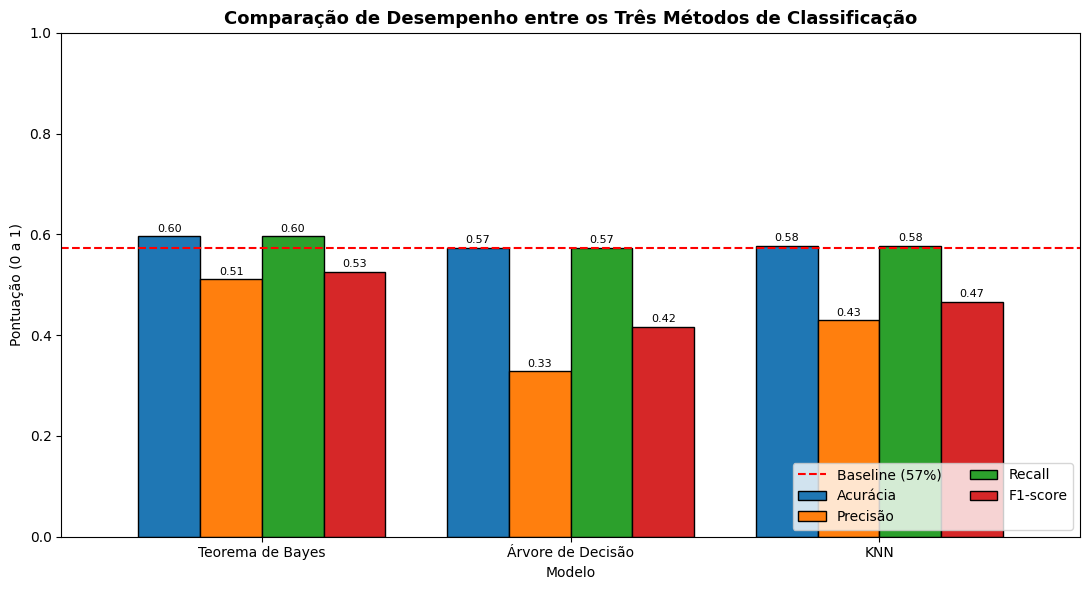

In [ ]:
# ===== COMPARAÇÃO 1 — Tabela e gráfico de métricas =====
tabela = pd.DataFrame(resultados).set_index("Modelo")
baseline = (y_test == "Home win").mean()      # acurácia de "chutar sempre Home win"

print("Comparação de métricas (conjunto de teste):\n")
print((tabela * 100).round(1).astype(str) + " %")
print(f"\nBaseline (sempre 'Home win'): {baseline*100:.1f} %")

# Gráfico de barras agrupadas: uma barra por métrica, para cada modelo
ax = tabela.plot(kind="bar", figsize=(11, 6), rot=0, edgecolor="black", width=0.8)
ax.axhline(baseline, color="red", linestyle="--", label=f"Baseline ({baseline*100:.0f}%)")
ax.set_title("Comparação de Desempenho entre os Três Métodos de Classificação",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Pontuação (0 a 1)")
ax.set_xlabel("Modelo")
ax.set_ylim(0, 1)
ax.legend(loc="lower right", ncol=2)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

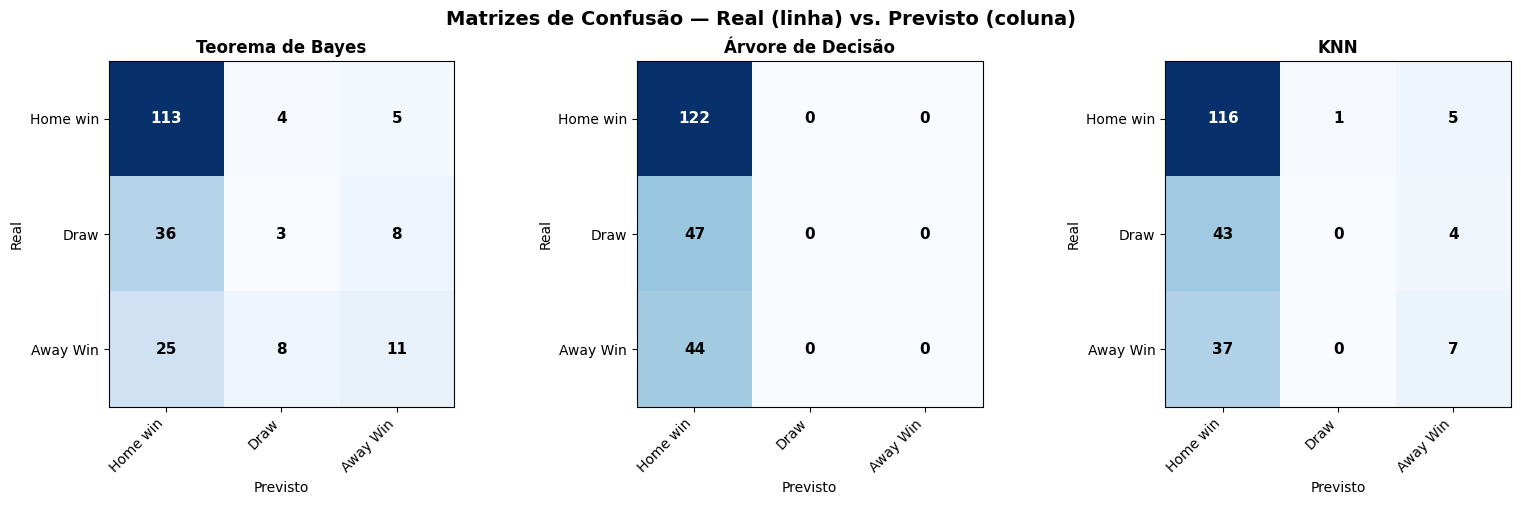

In [27]:
# ===== COMPARAÇÃO 2 — Matrizes de confusão lado a lado =====
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nome, y_pred) in zip(axes, predicoes.items()):
    cm = confusion_matrix(y_test, y_pred, labels=rotulos)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(nome, fontsize=12, fontweight="bold")
    ax.set_xticks(range(len(rotulos)), rotulos, rotation=45, ha="right")
    ax.set_yticks(range(len(rotulos)), rotulos)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
    # anota cada célula com a contagem
    for i in range(len(rotulos)):
        for j in range(len(rotulos)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=11, fontweight="bold")

fig.suptitle("Matrizes de Confusão — Real (linha) vs. Previsto (coluna)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 📌 Conclusões — Comparação entre os Três Métodos

| Método | Acurácia | Precisão | Recall | F1 (ponderado) | F1 (macro) |
|---|---|---|---|---|---|
| **Teorema de Bayes** | **59,6 %** | **51,1 %** | **59,6 %** | **52,6 %** | **0,39** |
| KNN (k=25) | 57,7 % | 42,9 % | 57,7 % | 46,6 % | 0,32 |
| Árvore de Decisão | 57,3 % | 32,8 % | 57,3 % | 41,7 % | 0,24 |
| *Baseline (sempre "Home win")* | *57,3 %* | — | — | — | — |

> O **F1 macro** (média simples das três classes, sem pesar pelo tamanho) é a métrica mais justa aqui, justamente por o dataset ser desbalanceado. Ele confirma o ranking: **Bayes (0,39) > KNN (0,32) > Árvore (0,24)**.

### Principais conclusões

1. **O Teorema de Bayes foi o melhor classificador.** Foi o único modelo a superar o *baseline* em todas as métricas, com o maior F1 (ponderado **52,6%** e macro **0,39**). Na matriz de confusão, é o **único método que ainda acerta algum empate** (recall de 6% em *Draw*, contra 0% dos outros dois) e o que tem o **melhor recall de vitória do visitante** (25% em *Away Win*) — ou seja, é o que menos ignora as classes minoritárias.

2. **A Árvore de Decisão "desistiu" das classes minoritárias.** Com acurácia de 57,3% — idêntica ao baseline — e *recall* zero tanto para *Draw* quanto para *Away Win*, ela aprendeu basicamente a **prever sempre "Home win"**. A acurácia parece aceitável, mas o F1 macro baixo (0,24) denuncia que o modelo praticamente não tem valor preditivo.

3. **O KNN ficou no meio-termo.** Superou a árvore (F1 macro 0,32) por **recuperar parte das vitórias do visitante** (recall 16% em *Away Win*), mas continuou **cego aos empates** (recall 0% em *Draw*).

4. **Por que os algoritmos de ML não brilharam?** Dois fatores: (a) **forte desbalanceamento** das classes (57% Home win), que faz a acurácia premiar quem só prevê a maioria; e (b) **poder preditivo limitado** das três variáveis escolhidas — fase, público e mandante explicam pouco da aleatoriedade de um jogo de futebol. A própria árvore confirmou isso: seus atributos mais informativos foram **`Home Team Name_Brazil`** e as faixas de público, ainda assim insuficientes.

### Como isso fundamenta o projeto

- A análise exploratória já apontava o **forte fator casa** (mandantes vencem ~57% das vezes); os três métodos **confirmam quantitativamente** que esse é o sinal dominante — tão dominante que algoritmos focados em acurácia tendem a só prever vitória do mandante.
- A **abordagem probabilística (Bayes)** se mostrou a mais adequada a este problema desbalanceado por entregar **probabilidades calibradas por classe** (e não apenas um rótulo), o que a torna mais útil para apoiar decisões — ex.: *"81% de chance de vitória do Brasil mandante"*.
- **Próximos passos sugeridos:** incluir atributos mais fortes (ranking/força das seleções, histórico de confrontos, fase específica), aplicar **balanceamento de classes** (`class_weight` ou SMOTE) e testar modelos como **Random Forest** ou **Regressão Logística** com regularização.